In [19]:
import random
import math
import numpy as np
import time

def print_matrix(M:np.ndarray):
    for row in M:
        row_rounded = [round(x, 2) for x in row]
        row_no_negative_zeros = [0.0 if math.isclose(x, 0.0) else x for x in row_rounded]
        print(" ".join(f"{x:.2f}" for x in row_no_negative_zeros))
    print()


def divide_row(row, k, M:np.ndarray):
    n = len(M)
    for j in range(n):
        M[row, j] /= k


def swap_rows(row1, row2, M:np.ndarray):
    n = len(M)
    for j in range(n):
        M[row1, j], M[row2, j] = M[row2, j], M[row1, j]


def add_scaled_row_to_another(row1, row2, k, M):
    n = len(M)
    for j in range(n):
        M[row2, j] += M[row1, j] * k


def gauss_elimination(M:np.ndarray, pivoting = True, normalize = True, b = None):
    n = len(M)
    M_res = np.copy(M)
    for j in range(n): 
        if pivoting:
            pivot_idx, maxi = j, abs(M_res[j, j])
            for i in range(j+1, n):
                if abs(M_res[i, j]) > maxi :
                    maxi, pivot_idx = abs(M_res[i, j]), i
            if pivot_idx != j: # we need to swap
                swap_rows(j, pivot_idx, M_res)

        if normalize:
            divide_row(j, M_res[j, j], M_res) # we want our row to have 1.0 as the element on the diagonal

        for k in range(j + 1, n):
            assert not np.isclose(M_res[j, j], 0)
            add_scaled_row_to_another(j, k, -M_res[k, j]/M_res[j, j], M_res) 
            
    return M_res


def inverse_matrix(M:np.ndarray):
    M_copy = np.copy(M)
    n = len(M_copy)
    M_res = np.zeros((n, n))
    for i in range(n):
        M_res[i, i] = 1
    
    for j in range(n):
        pivot_idx, maxi = j, np.abs(M_copy[j, j])
        for i in range(j+1, n):
            if abs(M_copy[i, j]) > maxi :
                maxi, pivot_idx = abs(M_copy[i, j]), i 

        if pivot_idx != j:
            swap_rows(j, pivot_idx, M_copy)
            swap_rows(j, pivot_idx, M_res)

        div = M_copy[j, j]
        divide_row(j, div, M_copy) 
        divide_row(j, div, M_res)

        for k in range(n):
            if k != j:
                scalar = -M_copy[k, j]
                add_scaled_row_to_another(j, k, scalar, M_copy) 
                add_scaled_row_to_another(j, k, scalar, M_res)

    return M_res


np.set_printoptions(precision=3, suppress=True)
n = 6
M1 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
M1 = np.array(M1)
M2 = np.copy(M1)


print()
# print_matrix(M1)
print(M1)
print("\nAFTER GAUSS ELIMINATION:\n")
print(gauss_elimination(M1))
# print_matrix(M1)


if np.linalg.det(M2) != 0:
    print("\nINVERSE MATRIX\n")
    # print_matrix(inverse_matrix(M2))
    print(inverse_matrix(M2))


[[ 8  4  6 13  0  0]
 [ 4 11  4  4  4  0]
 [14 10 10  1  7 10]
 [ 0  6  3 11 10 12]
 [ 2 13 11  4  9 14]
 [ 9  0  8  5 13 10]]

AFTER GAUSS ELIMINATION:

[[1 0 0 0 0 0]
 [0 1 0 0 0 1]
 [0 0 1 0 1 1]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]

INVERSE MATRIX

[[ 0.     0.     0.071  0.     0.     0.   ]
 [-0.021  0.067  0.     0.     0.027 -0.018]
 [ 0.1    0.067 -0.118 -0.143 -0.021  0.07 ]
 [ 0.077  0.    -0.003  0.    -0.024 -0.058]
 [-0.121  0.     0.049  0.143 -0.029  0.037]
 [ 0.021 -0.067 -0.011 -0.     0.05   0.018]]


In [2]:
def gauss_numpy(A, pivoting = True, normalize = True, b = None):
    m = len(A)
    A = np.array(A, dtype=np.float64)
    if b is not None:
        b = np.array(b, dtype=np.float64)

    for i in range(m):
        if pivoting or np.isclose(A[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(A[i:, i]))
            else:
                try:
                    pivot_idx = i + np.where(~np.isclose(np.abs(A[i:, i]), 0.0))[0][0]
                except IndexError:
                    print("No nonzero found in column\n", A[i:, i])
            
            if pivot_idx != i:
                A[[i, pivot_idx]] = A[[pivot_idx, i]]
                if b is not None:
                    b[i], b[pivot_idx] = b[pivot_idx], b[i]

        assert not np.isclose(A[i, i], 0.0)

        if normalize:
            pivot_val = A[i, i]
            A[i, :] /= pivot_val
            if b is not None:
                b[i] /= pivot_val

        for j in range(i+1, m):
            factor = A[j][i]/A[i, i]
            A[j, :] -= factor * A[i, :]
            if b is not None:
                b[j] -= factor * b[i]
    return A, b


def back_substitution(U:np.ndarray, b:np.ndarray):
    x = np.zeros_like(b)
    nn = U.shape[0]
    for i in range(nn-1, -1, -1):
        x[i] = (b[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x


def lu_factorization(A, pivoting = True):
    n = len(A)
    P = [i for i in range(n)]
    A = np.array(A, dtype=np.float64)
    L, U = np.array([[0.0 for _ in range(n)] for _ in range(n)]), np.copy(A)
    for i in range(n):
        L[i, i] = 1.0
    for i in range(n):
        
        if pivoting or np.isclose(U[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(U[i:, i]))
            else:
                pivot_idx = i + np.where(~np.isclose(np.abs(U[i:, i]), 0.0))[0][0]
        
            if pivot_idx != i:
                U[[i, pivot_idx]] = U[[pivot_idx, i]]
                L[[i, pivot_idx], :i] = L[[pivot_idx, i], :i]
                P[i], P[pivot_idx] = P[pivot_idx], P[i]

            assert not np.isclose(U[i, i], 0.0)

        for j in range(i+1, n):
            factor = U[j][i]/U[i, i]
            U[j, :] -= factor * U[i, :]
            L[j, i] = factor

    P = np.array(P)
    P_res = np.zeros((P.size, P.max() + 1))
    P_res[np.arange(P.size), P] = 1
    return P_res, L , U


def assert_l_matrix(L, tol):
    identity = np.eye(L.shape[0])
    L_tr = np.triu(L) # eliminates nonzero elements of upper diagonal part
    assert np.allclose(L_tr - identity, np.zeros_like(L), atol = tol) # checks ones on diagonal


def assert_u_matrix(U, tol, has_ones = False):
    U_tr = np.tril(U, (-1 if not has_ones else 0) )
    if has_ones:
        U_tr -= np.eye(U.shape[0])
    assert np.allclose(U_tr, 0, atol=tol)



In [3]:
global adds2, muls2
adds2 = 0
muls2 = 0

def add_matrices(A,B):
    global adds2
    adds2 += A.shape[0] * A.shape[0]
    return np.add(A,B)

def subtract_matrices(A, B):
    global adds2
    adds2 += A.shape[0] * A.shape[0]
    return np.subtract(A, B)

def strassen_alg(A1, B1):
    global adds2, muls2
    def strassen_core(A, B):
        global adds2, muls2

        if(A.shape[0] == 1):

            C = np.multiply(A, B.transpose())
            muls2 += A.shape[1]
            return C
        
        n_prev = A.shape[0]
        m_prev = B.shape[1]
        
        mid = A.shape[0]//2

        A00 = A[:mid, :mid]
        A01 = A[:mid, mid:]
        A10 = A[mid:, :mid]
        A11 = A[mid:, mid:]

        B00 = B[:mid, :mid]
        B01 = B[:mid, mid:]
        B10 = B[mid:, :mid]
        B11 = B[mid:, mid:]

        M1 = strassen_core(add_matrices(A00, A11), add_matrices(B00, B11))
        M2 = strassen_core(add_matrices(A10, A11), B00)
        M3 = strassen_core(A00, subtract_matrices(B01, B11))
        M4 = strassen_core(A11, subtract_matrices(B10, B00))
        M5 = strassen_core(add_matrices(A00, A01), B11)
        M6 = strassen_core(subtract_matrices(A10, A00), add_matrices(B00, B01))
        M7 = strassen_core(subtract_matrices(A01, A11), add_matrices(B10, B11))

        result = np.zeros((2 * mid, 2 * mid), dtype=np.float64)
        result[:mid, :mid] = add_matrices(add_matrices(M1, M4), subtract_matrices(M7, M5))
        result[:mid, mid:] = add_matrices(M3, M5)
        result[mid:, :mid] = add_matrices(M2, M4)
        result[mid:, mid:] = add_matrices(subtract_matrices(M1, M2), add_matrices(M3, M6))
        return result[:n_prev, :m_prev]
    
    pot = 1
    max_shape = max(max(A1.shape), max(B1.shape))
    while(pot < max_shape):
        pot *= 2
    B1_prev = B1.shape[1]
    A1_prev = A1.shape[0]
    B1 = np.pad(B1, ((0, pot - B1.shape[0]), (0, pot - B1.shape[1])), mode = "constant", constant_values = 0)
    A1 = np.pad(A1, ((0, pot - A1.shape[0]), (0, pot - A1.shape[1])), mode = "constant", constant_values = 0)
    res1 = strassen_core(A1, B1)
    return res1[:A1_prev, :B1_prev]


def get_mult_res(A, B):
    res = strassen_alg(A, B)
    return res


def inverse_recursive(A1):
    n = A1.shape[0]
    if(n == 1):
        return 1/A1
    mid = n//2
    
    A11 = A1[:mid, :mid]
    A12 = A1[:mid, mid:]
    A21 = A1[mid:, :mid]
    A22 = A1[mid:, mid:]

    A11_inv = inverse_recursive(A11)

    S22 = subtract_matrices(A22, get_mult_res(get_mult_res(A21, A11_inv), A12))

    S22_inv = inverse_recursive(S22)
    
    B11 = get_mult_res(A11_inv, add_matrices(np.identity(mid), get_mult_res(get_mult_res(A12, S22_inv), get_mult_res(A21, A11_inv))))
    B12 = (-1) * get_mult_res(get_mult_res(A11_inv, A12), S22_inv)
    B21 = (-1) * get_mult_res(get_mult_res(S22_inv, A21), A11_inv)
    B22 = S22_inv
    result = np.zeros((n, n), dtype=np.float64)
    result[:mid, :mid] = B11
    result[:mid, mid:] = B12
    result[mid:, :mid] = B21
    result[mid:, mid:] = B22
    return result[:n, :n]


def LU_factor(A):
    n = A.shape[0]
    if(n == 1):
        return A, np.array([[1]])
    
    mid = n//2
    A11 = A[:mid, :mid]
    A12 = A[:mid, mid:]
    A21 = A[mid:, :mid]
    A22 = A[mid:, mid:]


    L11, U11 = LU_factor(A11)
    U11_inv = inverse_recursive(U11)
    L21 = get_mult_res(A21, U11_inv)
    L11_inv = inverse_recursive(L11)
    U12 = get_mult_res(L11_inv, A12)
    S = subtract_matrices(A22, get_mult_res(get_mult_res(get_mult_res(A21, U11_inv), L11_inv), A12))
    Ls, Us = LU_factor(S)
    U22 = Us
    L22 = Ls
    
    U_res = np.zeros((n, n), dtype=np.float64)
    U_res[:mid, :mid] = U11
    U_res[:mid, mid:] = U12
    U_res[mid:, mid:] = U22
    L_res = np.zeros((n, n), dtype=np.float64)
    L_res[:mid, :mid] = L11
    L_res[mid:, :mid] = L21
    L_res[mid:, mid:] = L22
    return L_res[:n, :n], U_res[:n, :n]


def matrix_naive(A, B):
    global muls2, adds2
    n = A.shape[0]
    if(len(B.shape) == 1):
        B = np.expand_dims(B, axis=1)
    m = B.shape[1]
    res = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            for k in range(A.shape[1]):
                res[i, j] += A[i, k] * B[k, j]
                muls2 += 1
                adds2 += 1
    return res


def Gauss_recursive(A, b):
    n = len(A)
    B = np.copy(b)
    if(n == 1):
        return A, B
    mid = n//2

    A11 = A[:mid, :mid]
    A12 = A[:mid, mid:]
    A21 = A[mid:, :mid]
    A22 = A[mid:, mid:]

    b1 = B[:mid, 0]
    b2 = B[mid:, 0] 

    L11, U11 = LU_factor(A11)
    L11_inv = inverse_recursive(L11)
    U11_inv = inverse_recursive(U11)
    S = subtract_matrices(A22, get_mult_res(get_mult_res(get_mult_res(A21, U11_inv), L11_inv), A12))
    Ls, Us = LU_factor(S)
    Ls_inv = inverse_recursive(Ls)

    C11 = U11
    C12 = get_mult_res(L11_inv, A12)
    C22 = Us

    b1_new = matrix_naive(L11_inv, b1)
    b2_new = subtract_matrices(matrix_naive(Ls_inv, b2), matrix_naive(get_mult_res(get_mult_res(get_mult_res(Ls_inv, A21), U11_inv), L11_inv ), b1 ))

    Gauss_res = np.zeros((n, n), dtype=np.float64)
    Gauss_res[:mid, :mid] = C11
    Gauss_res[:mid, mid:] = C12
    Gauss_res[mid:, mid:] = C22
    Gauss_res[mid:, :mid] = np.zeros((n-mid, mid))
    
    B_res = np.zeros((n, 1))
    B_res[:mid] = b1_new
    B_res[mid:] = b2_new

    return Gauss_res[:n, :n], B_res[:n, 0]

In [18]:
# M1 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
# M1 = np.array(M1)

np.set_printoptions(precision=3, suppress=True)

M1 = np.array([[ 5,  6, 15, 12,  8, 13],
               [ 5,  9, 15, 14, 10, 14],
               [ 2,  4,  3, 11,  6, 11],
               [ 7,  1,  9,  6,  3,  9],
               [ 4,  8, 15, 15,  1, 10],
               [13,  0, 12,  9,  0,  8]])
M2 = np.copy(M1)

print("STARTING MATRIX:\n")
print(M1)
print("\nGAUSS ITERATIVE WITHOUT NUMPY:\n")
print(gauss_elimination(M1))

rng = np.random.default_rng()
v = rng.random((M1.shape[0], 1))
print("\nGAUSS ITERATIVE WITH NUMPY:\n")
print(gauss_numpy(M1, b = v)[0])
print("\nGAUSS BLOCK MATRIX WITH NUMPY:\n")
print(Gauss_recursive(M1, v)[0])
print()



STARTING MATRIX:

[[ 5  6 15 12  8 13]
 [ 5  9 15 14 10 14]
 [ 2  4  3 11  6 11]
 [ 7  1  9  6  3  9]
 [ 4  8 15 15  1 10]
 [13  0 12  9  0  8]]

GAUSS ITERATIVE WITHOUT NUMPY:

[[ 1  0  0  0  0  0]
 [ 0  1  1  1  1  1]
 [ 0  0  1  0  0  0]
 [ 0  0  0  1 -1  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  0  1]]

GAUSS ITERATIVE WITH NUMPY:

[[ 1.     0.     0.923  0.692  0.     0.615]
 [ 0.     1.     1.154  1.171  1.111  1.214]
 [-0.    -0.     1.    -1.425 -0.449 -1.42 ]
 [ 0.     0.     0.     1.     0.448  1.172]
 [-0.    -0.    -0.    -0.     1.     0.632]
 [ 0.     0.     0.     0.     0.     1.   ]]

GAUSS BLOCK MATRIX WITH NUMPY:

[[ 1.     1.2    3.     2.4    1.6    2.6  ]
 [ 0.     1.     0.     0.667  0.667  0.333]
 [ 0.     0.     1.    -1.711 -0.578 -1.756]
 [ 0.     0.     0.     1.     0.386  1.053]
 [ 0.     0.     0.     0.     1.     0.558]
 [ 0.     0.     0.     0.     0.     1.   ]]



In [17]:
np.set_printoptions(precision=3, suppress=True)

print("STARTING MATRIX:\n")
print(M2)
print("\nINVERSE WITHOUT NUMPY:\n")
print(inverse_matrix(M2))
print("\nINVERSE BLOCK MATRIX WITH NUMPY:\n")
print(inverse_recursive(M2))

STARTING MATRIX:

[[13  2  5  0  7  2]
 [ 9  2  6 11  7 11]
 [ 6 14  6  7  6 10]
 [ 0 10  2  5 12  5]
 [ 4  7 11  5  0  5]
 [14  7 10  7 13  2]]

INVERSE WITHOUT NUMPY:

[[ 0.     0.     0.     0.     0.     0.071]
 [ 0.     0.     0.071  0.     0.    -0.031]
 [ 0.     0.    -0.045  0.     0.091 -0.006]
 [-0.5   -0.042 -0.229  0.292  0.197  0.533]
 [ 0.    -0.038 -0.057  0.083  0.006  0.047]
 [ 0.5    0.133  0.241 -0.292 -0.247 -0.582]]

INVERSE BLOCK MATRIX WITH NUMPY:

[[ 0.009 -0.006  0.083 -0.101 -0.076  0.053]
 [-0.049 -0.066  0.117 -0.046 -0.043  0.05 ]
 [ 0.059 -0.001 -0.12   0.079  0.16  -0.048]
 [-0.203  0.037  0.069 -0.112 -0.092  0.161]
 [ 0.06   0.014 -0.092  0.12   0.022 -0.031]
 [ 0.134  0.063 -0.034  0.084  0.06  -0.167]]


In [5]:
import matplotlib.pyplot as plt
from collections import defaultdict

NUM_TRIALS = 10000
n = 40

lu_pivot_diff = defaultdict(list)
with_error, without_error = 0, 0
for i in range(NUM_TRIALS):
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')

    M3 = [[random.random() * 10 for _ in range(n)] for _ in range(n)]
    M3 = np.array(M3)
    
    P2, L2, U2 = lu_factorization(M3)
    P3, L3, U3 = lu_factorization(M3, False)

    for j, (Lj, Uj, tol) in enumerate([[L2, U2, 5e-6], [L3, U3, 2e-2]]):
        try:
            assert_l_matrix(Lj, tol)
            assert_u_matrix(Uj, tol)
        except Exception as e:
            if j == 0:
                with_error += 1
            else:
                without_error += 1

    for func, label in [[lambda x: np.max(np.abs(x)), "max"], [lambda x: np.mean(x), "mean"],
        [lambda x: np.median(x), "median"]]:

        pivot, no_pivot = func(P2 @ M3 - L2 @ U2), func(P3 @ M3 - L3 @ U3)
        
        if pivot == 0:
            if no_pivot == 0:
                diff_i = 1
            else:
                print(f"Pivot is zero but no pivot is not: {no_pivot}")
                diff_i = no_pivot/np.finfo(np.float64).tiny
        else:
            diff_i = no_pivot/pivot

        lu_pivot_diff[label].append([no_pivot, pivot, no_pivot/pivot if pivot != 0 else None])
    

pivot_diff = np.array(lu_pivot_diff)

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [6]:
lu_pivot_max = np.array(lu_pivot_diff["max"])
lu_pivot_mean = np.array(lu_pivot_diff["mean"])
lu_pivot_median = np.array(lu_pivot_diff["median"])

In [7]:
print(f"Outside the tolerance: pivot = {with_error}/{NUM_TRIALS}, no_pivot = {without_error}/{NUM_TRIALS}")

Outside the tolerance: pivot = 1/10000, no_pivot = 397/10000


Lims: (0, 249.15)
Median of max no pivot: 0.00015938487446898186
Median of max with pivot 3.776794464727118e-06
Max max difference: 636028
Lims: (0, 103.92)
Median of mean no pivot: -2.0815448105026158e-10
Median of mean with pivot -1.1379040643988773e-10
Max mean difference: 455795
Lims: (0, 7.41)
Median of median no pivot: 1.495469094696042e-10
Median of median with pivot -7.68204388990057e-11
Max median difference: 12140


<Figure size 2000x900 with 0 Axes>

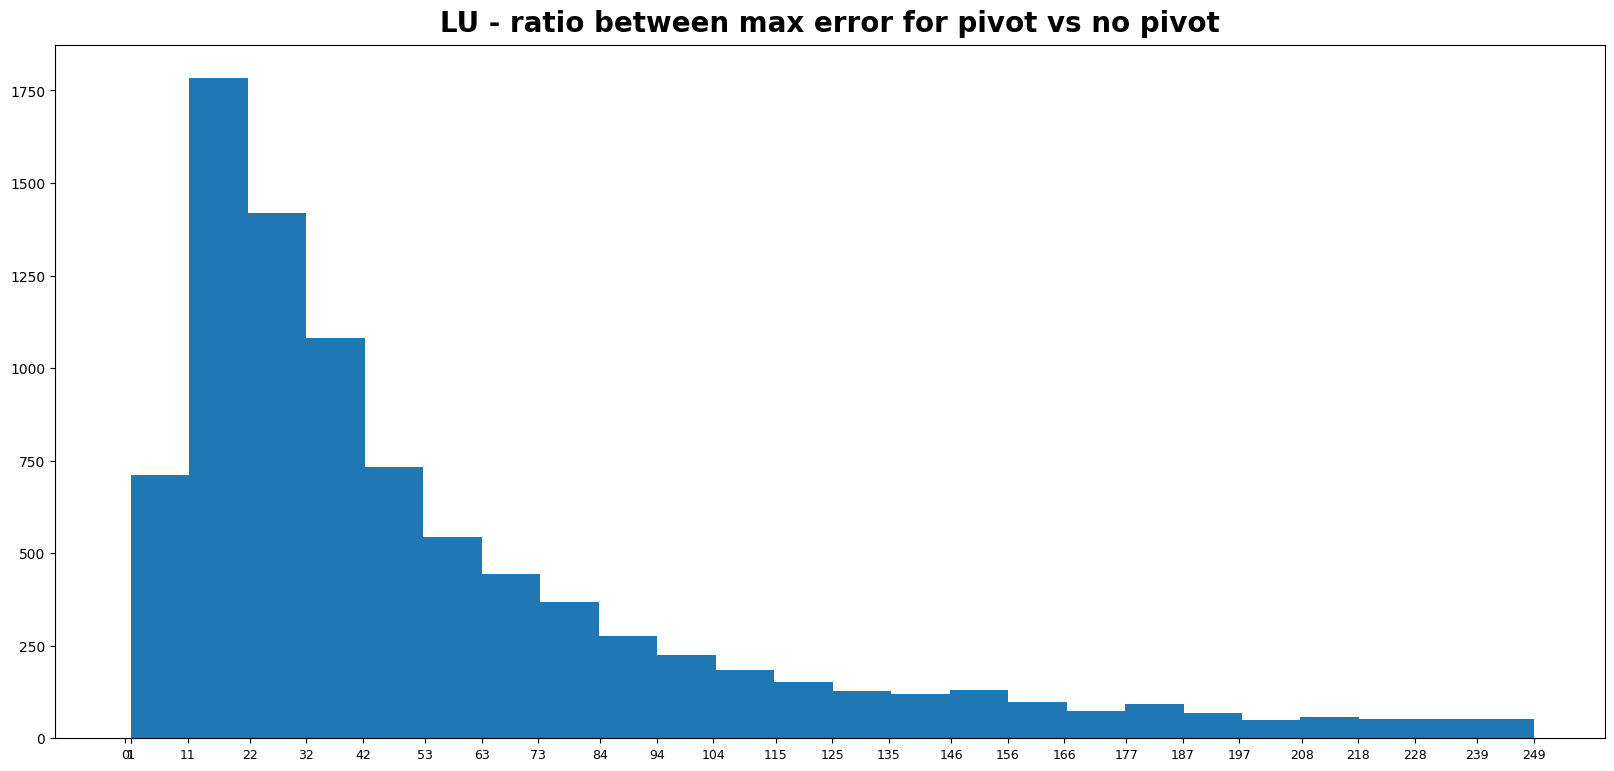

<Figure size 2000x900 with 0 Axes>

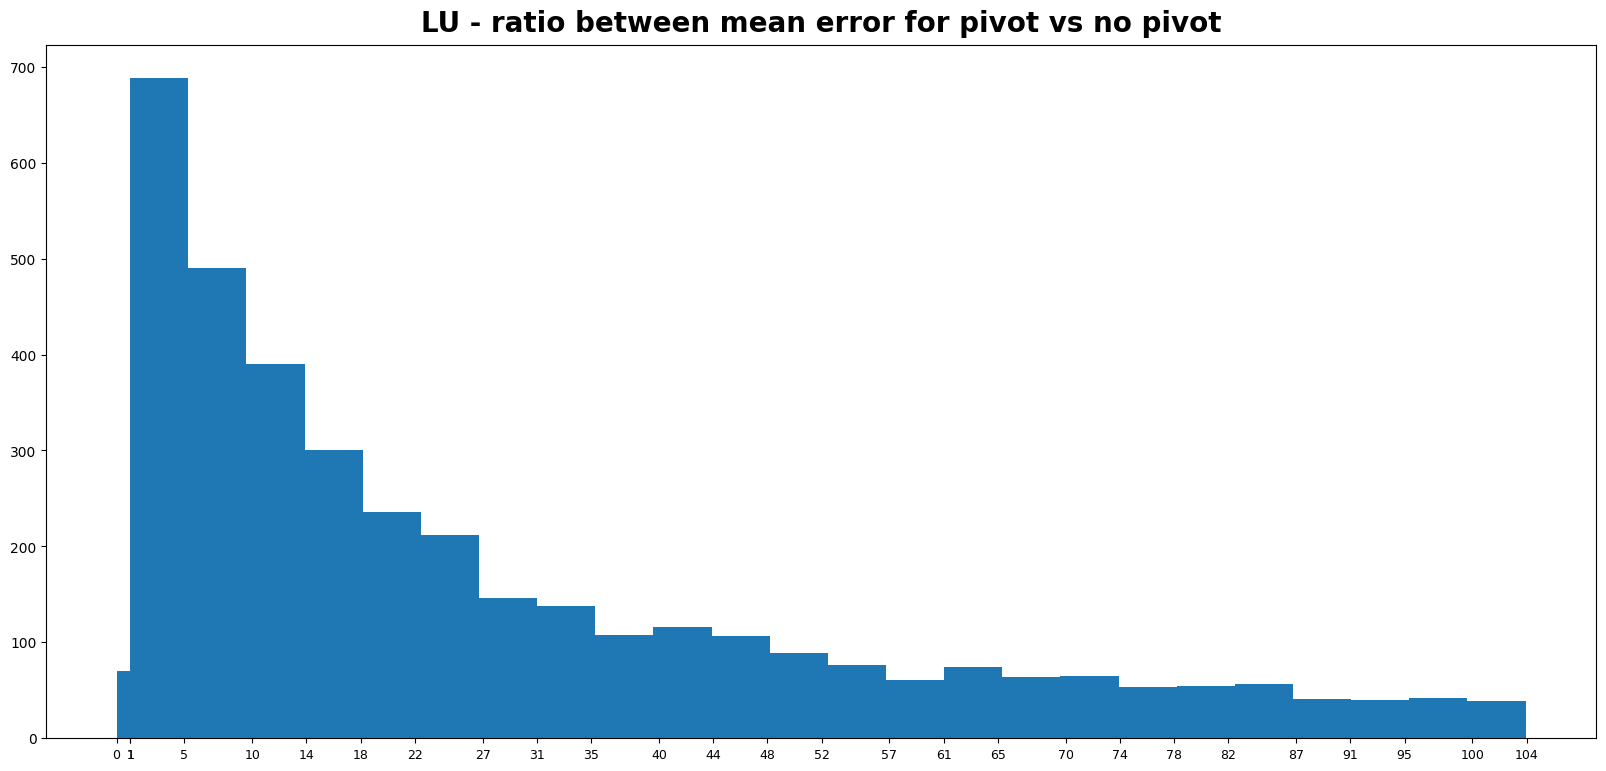

<Figure size 2000x900 with 0 Axes>

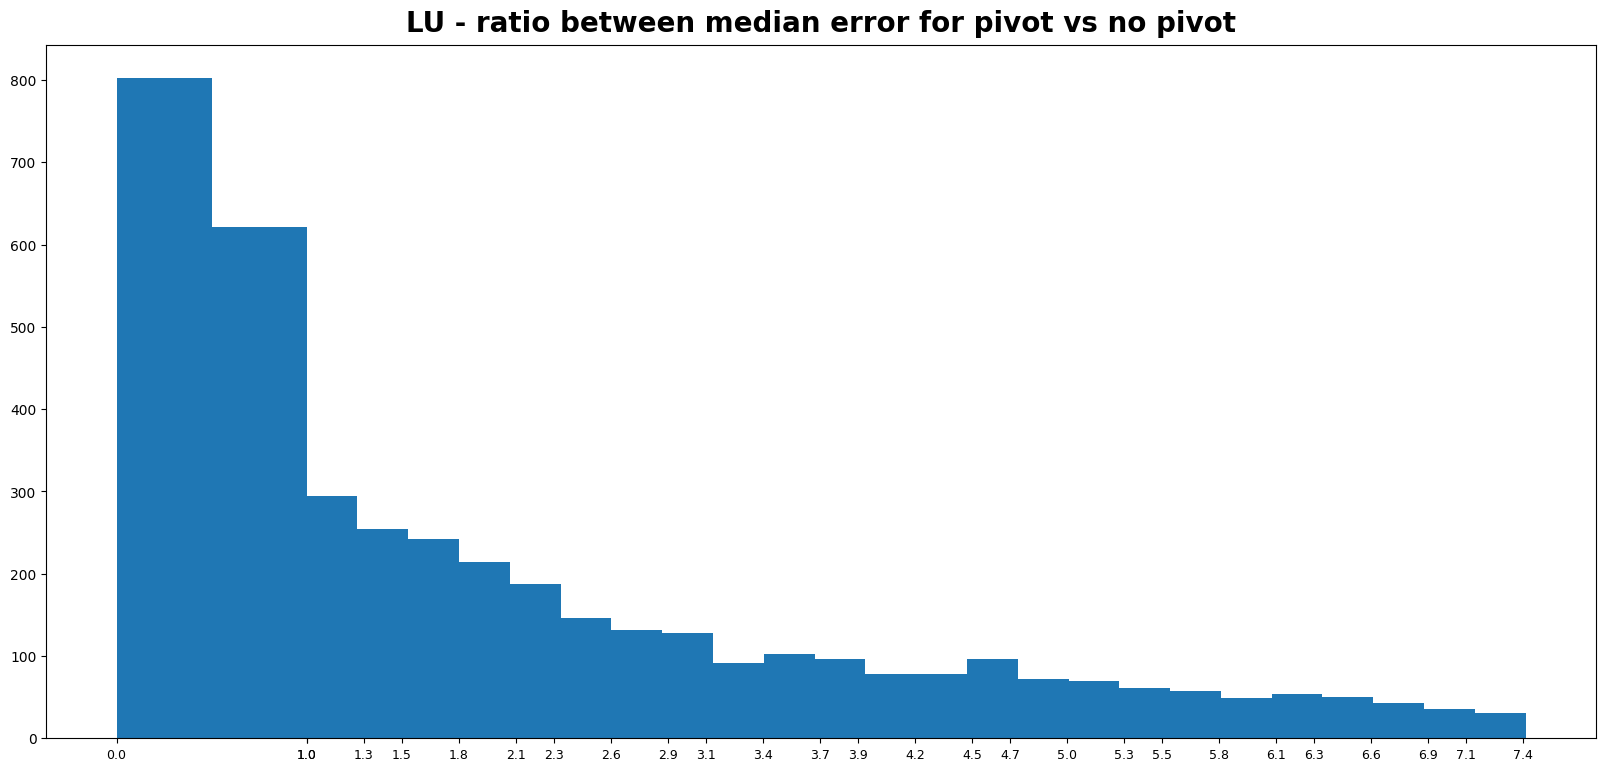

In [8]:
labels = ["max", "mean", "median"]

def custom_rand(num, bound):
    if bound < 0.01:
        return round(num, 4)
    if bound < 0.1:
        return round(num, 3)
    if bound < 1:
        return round(num, 2)
    if bound < 15:
        return round(num, 1)
    return round(num)


for i, metric_res in enumerate([lu_pivot_max, lu_pivot_mean, lu_pivot_median]):
    lu_lims = [0, np.percentile(metric_res[:, 2], 89)]
    k = 25
    s = 15

    print(f"Lims: ({lu_lims[0]}, {round(lu_lims[1], 2)})")

    plt.figure(figsize=(20, 9))
    plt.figure(figsize=(20, 9))

    bins = np.concatenate([
        [0.0, 0.5, 1.0],
        np.linspace(1.0, lu_lims[1], k)[1:]
    ])

    plt.hist(metric_res[:, 2], bins=bins)
    plt.xticks([0.0, 1.0] + [custom_rand(bin, lu_lims[1]) for bin in bins[2:]], fontsize = 9)

    plt.title(f"LU - ratio between {labels[i]} error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )
    plt.plot()

    print(f"Median of {labels[i]} no pivot:", np.median(metric_res[:, 0]))
    print(f"Median of {labels[i]} with pivot", np.median(metric_res[:, 1]))

    idx_max = np.argmax(metric_res[:, 2])

    print(f"Max {labels[i]} difference:", round(np.max(metric_res[:, 2])))

In [9]:
gauss_pivot_diff = defaultdict(list)

NUM_TRIALS = 10000
n = 40
zero_nonzero_cases = 0

for i in range(NUM_TRIALS):
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')
        
    A = np.array([[random.random() * 15 for _ in range(n)] for _ in range(n)], dtype=np.float64)
    x = np.array([random.random() * 100 for _ in range(n)], dtype=np.float64)
    b = np.dot(A, x)

    for func, label in [[lambda x: np.max(np.abs(x)), "max"], [lambda x: np.mean(x), "mean"],
                     [lambda x: np.median(x), "median"]]:
        
        U1, b1 = gauss_numpy(A, pivoting=False, b = b)
        x_without = back_substitution(U1, b1)
        no_pivot = func(x_without - x)

        U2, b2 = gauss_numpy(A, pivoting=True, b = b)
        x_with = back_substitution(U2, b2)
        pivot = func(x_with - x)

        if pivot == 0:
            if no_pivot == 0:
                diff_i = 1
            else:
                zero_nonzero_cases += 1
                # print(f"Pivot is zero but no pivot is not: {no_pivot}")
                diff_i = no_pivot/np.finfo(np.float64).tiny
        else:
            diff_i = no_pivot/pivot

        arr = gauss_pivot_diff[label].append([no_pivot, pivot, diff_i])
    

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [10]:
print(f"Zero pivot but nonzero no pivot cases: {zero_nonzero_cases}/{NUM_TRIALS}")

Zero pivot but nonzero no pivot cases: 208/10000


In [11]:
gauss_pivot_max = np.array(gauss_pivot_diff["max"], dtype = np.float64)
gauss_pivot_mean = np.array(gauss_pivot_diff["mean"], dtype = np.float64)
gauss_pivot_median = np.array(gauss_pivot_diff["median"], dtype = np.float64)

Lims: (0, 117.25)
Median of max no pivot: 2.6758595339515523e-11
Median of max with pivot: 1.4352963262354024e-12
Max max difference: 305812
Lims: (0, 73.66)
Median of mean no pivot: 3.658184866139891e-15
Median of mean with pivot: 8.881784197001253e-17
Max mean difference: 155072800370228663556489221270873838565641098907094844442624392350392493128565285891417909023365298803748309747781783802591960990223018551713501930014252282357231274171471584247015799316965448246004543271853532962291228888748419878852225893048950568927280615058023515902153716100063306050772664320
Lims: (0, 77.01)
Median of median no pivot: 8.770761894538737e-15
Median of median with pivot: 0.0
Max median difference: 17712843246283494162072909063476377853220701842213433425930126470961163074910031808153607748791282730883783494648587092190826110454434536507820861009162084675569611946760131248811965173292148187687586622705017980169931743091943110196941923844844178132576797194013509778850934562149875446828786253824


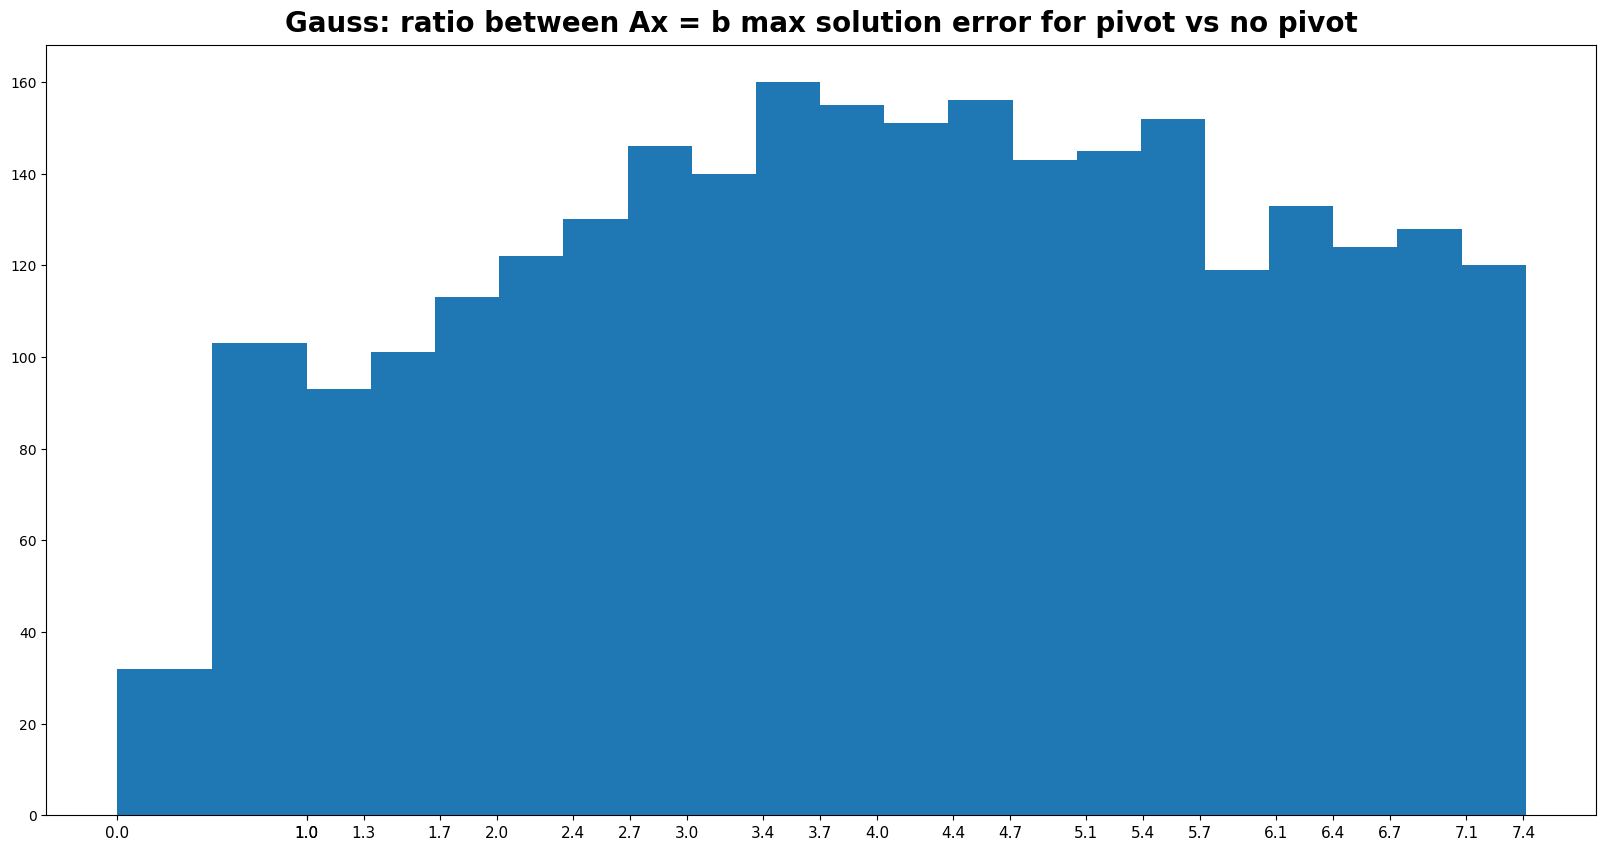

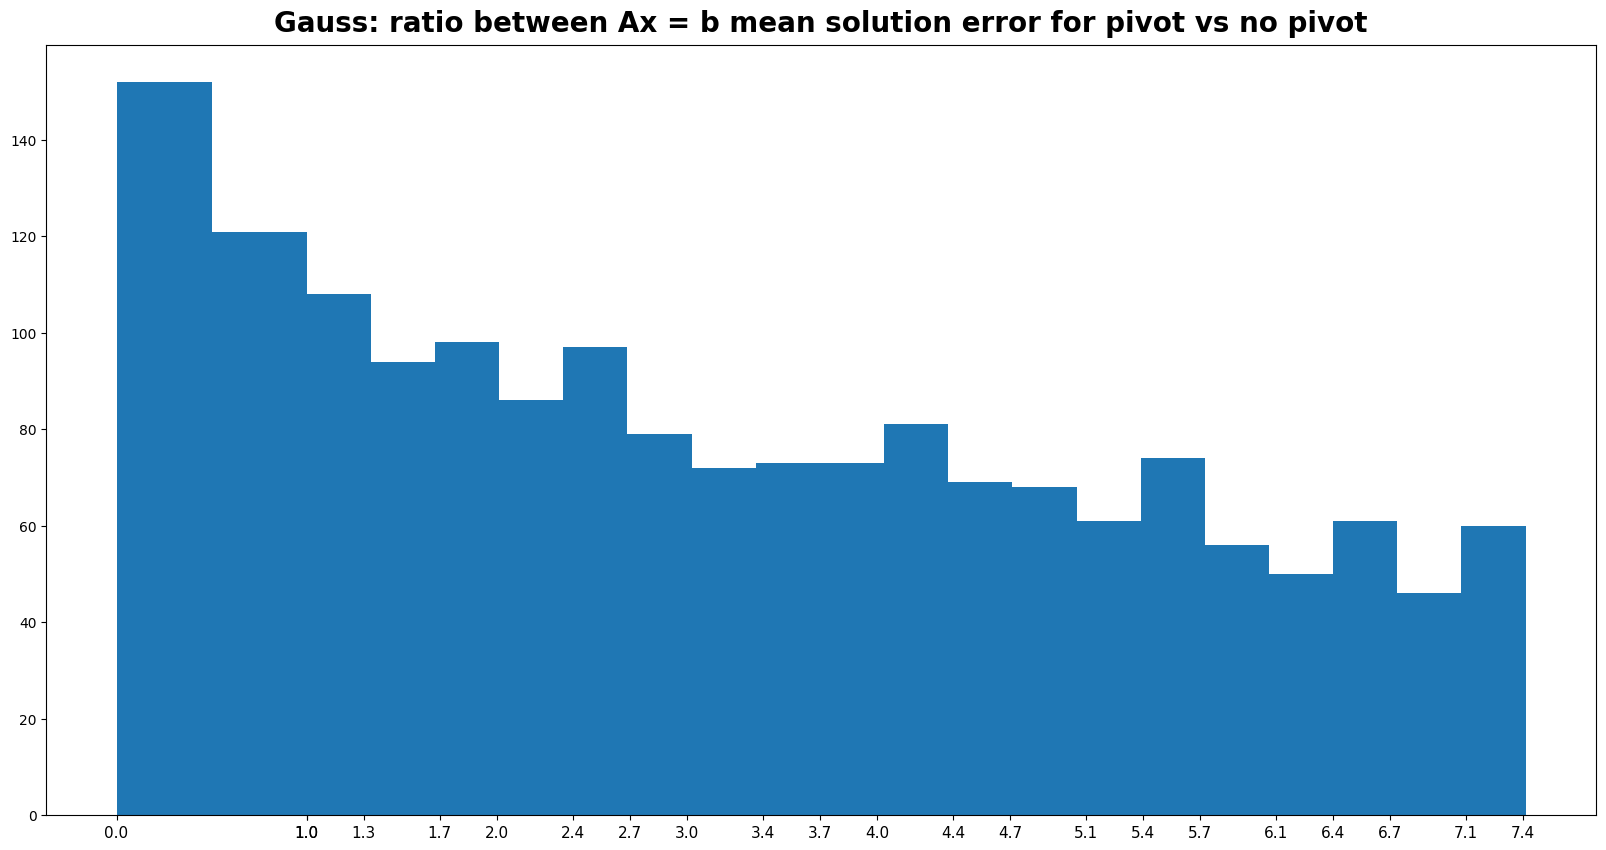

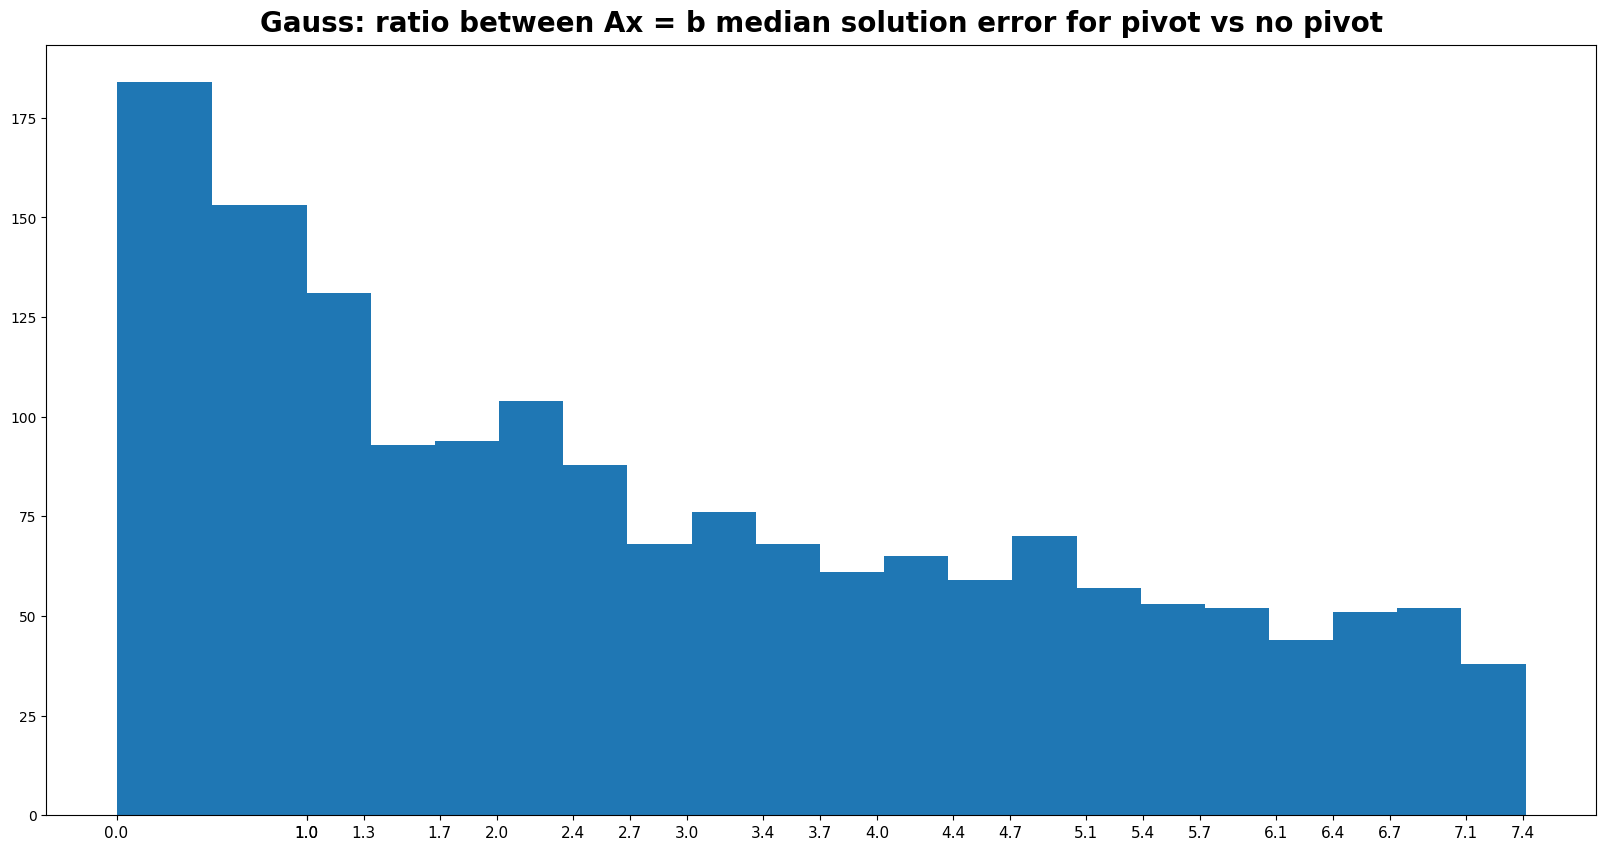

In [12]:
labels = ["max", "mean", "median"]
for i, metric_res in enumerate([gauss_pivot_max, gauss_pivot_mean, gauss_pivot_median]):
    gauss_lims = [0, np.percentile(metric_res[:, 2], 89)]
    s = 15

    print(f"Lims: ({gauss_lims[0]}, {round(gauss_lims[1], 2)})")

    plt.figure(figsize=(20, 10))
    min_val, max_val = gauss_lims[0], gauss_lims[1]

    k = 20

    bins = np.concatenate([
        [0.0, 0.5, 1.0],
        np.linspace(1.0, lu_lims[1], k)[1:]
    ])

    plt.hist(metric_res[:, 2], bins = bins)
    
    plt.xticks([0.0, 1.0] + [custom_rand(bin, lu_lims[1]) for bin in bins[2:]], fontsize = 11)
    plt.title(f"Gauss: ratio between Ax = b {labels[i]} solution error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )

    print(f"Median of {labels[i]} no pivot:", np.median(metric_res[:, 0]))
    print(f"Median of {labels[i]} with pivot:", np.median(metric_res[:, 1]))
    print(f"Max {labels[i]} difference:", round(np.max(metric_res[:, 2])))

### Example tests

In [7]:
A = np.array([[random.random() * 20 for _ in range(5)] for _ in range(5)])
x = np.array([random.random() * 50 for _ in range(5)])
b = np.dot(A, x)

print("b:\n", b, sep = '')

U2, b2 = gauss_numpy(A, pivoting = False, b = b)

print("Diagonal Gauss:", U2.diagonal())
print("b2:\n", b2, sep='')

x2 = back_substitution(U2, b2)

print("x:\n", x, sep = '')
print("x_solved:\n", x2, sep = '')

b:
[ 628.936  800.628 1897.949 1338.451 1686.472]
Diagonal Gauss: [1. 1. 1. 1. 1.]
b2:
[220.206 295.167 114.893  24.079  34.071]
x:
[24.504 48.526 14.974 26.378 34.071]
x_solved:
[24.504 48.526 14.974 26.378 34.071]


In [9]:
import time
from enum import Enum

class MatFunction(Enum):
    GAUSS = 1
    INV = 2
    LU = 3
    MULT = 4
    
def measure_times(sizes, func, func_type:MatFunction):
    T_times = []
    
    for n in sizes:
        rng = np.random.default_rng()

        A = (rng.random((n, n)) * 5.0 + 1e-8).astype(np.longdouble)
        rng = np.random.default_rng()
        
        start_time = time.time()

        if func_type == MatFunction.GAUSS:
            v = rng.random((n, 1))
            _ = func(A, b = v) 
        elif func_type in [MatFunction.LU, MatFunction.INV]:
            _ = func(A)
        elif func_type == MatFunction.MULT:
            B = rng.random((n, n))
            _ = func(A, B)
        
        print(n, end = ' ')
        T_times.append(time.time() - start_time)

        
    return T_times

sizes = [2**i for i in range(1, 8 + 1)]
gauss_no_numpy_times = measure_times(sizes, gauss_elimination, MatFunction.GAUSS)
print()
gauss_numpy_times = measure_times(sizes, gauss_numpy, MatFunction.GAUSS)
print()
gauss_numpy_block_times = measure_times(sizes, Gauss_recursive, MatFunction.GAUSS)

2 4 8 16 32 64 128 256 
2 4 8 16 32 64 128 256 
2 4 8 16 32 64 128 256 

In [10]:
inv_no_numpy_times = measure_times(sizes, inverse_matrix, MatFunction.INV)
print()
inv_numpy_block_times = measure_times(sizes, inverse_recursive, MatFunction.INV)

2 4 8 16 32 64 128 256 
2 4 8 16 32 64 128 256 

In [11]:
lu_numpy_times = measure_times(sizes, lu_factorization, MatFunction.LU)
print()
lu_block_times = measure_times(sizes, LU_factor, MatFunction.LU)

2 4 8 16 32 64 128 256 
2 4 8 16 32 64 128 256 

In [20]:
mult_numpy_times = measure_times(sizes, lambda x, y : np.dot(x, y), MatFunction.MULT)
print()
mult_no_numpy_times = measure_times(sizes, matrix_naive, MatFunction.MULT)
print()
mult_block_times = measure_times(sizes, strassen_alg, MatFunction.MULT)

2 4 8 16 32 64 128 256 
2 4 8 16 32 64 128 256 
2 4 8 16 32 64 128 256 

In [15]:
import matplotlib.pyplot as plt
def plot_times_all(sizes, times_list, algorithm_names, log_scale = True):

    fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

    for times, name in zip(times_list, algorithm_names):
        ax1.plot(sizes, times, label=f'{name}')
        
    ax1.set_xlabel('Matrix Size')
    ax1.set_ylabel('Time (s)')
    ax1.set_title('Execution Time for Algorithms')
    if log_scale:
        ax1.set_yscale('log')
    ax1.grid(True)
    ax1.legend()

    plt.tight_layout()
    plt.show()

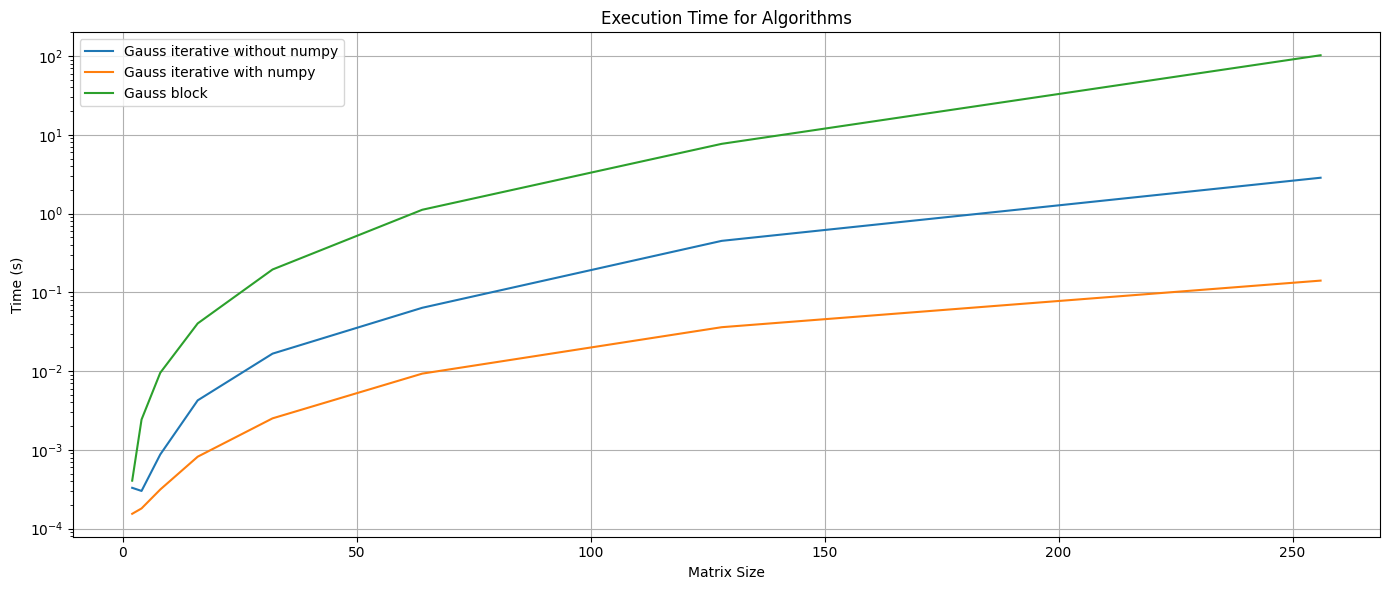

In [16]:
plot_times_all(sizes, [gauss_no_numpy_times, gauss_numpy_times, gauss_numpy_block_times], ["Gauss iterative without numpy", "Gauss iterative with numpy", "Gauss block"])

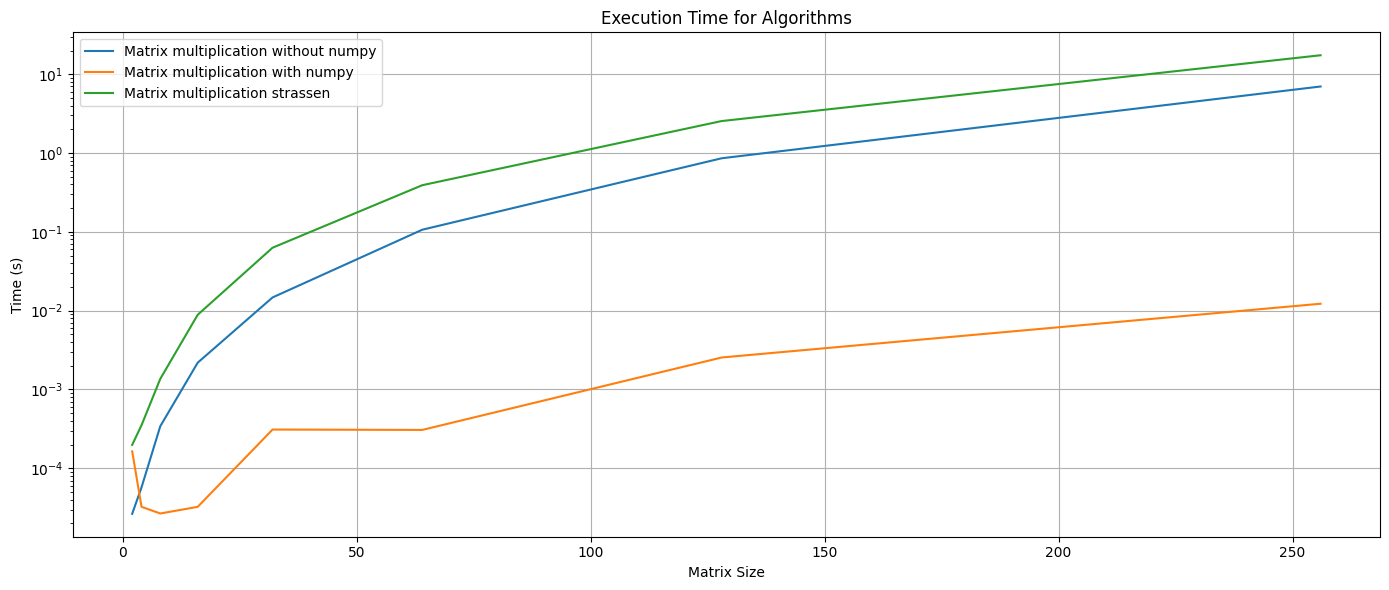

In [23]:
plot_times_all(sizes, [mult_no_numpy_times, mult_numpy_times, mult_block_times], ["Matrix multiplication without numpy", "Matrix multiplication with numpy", "Matrix multiplication strassen"])

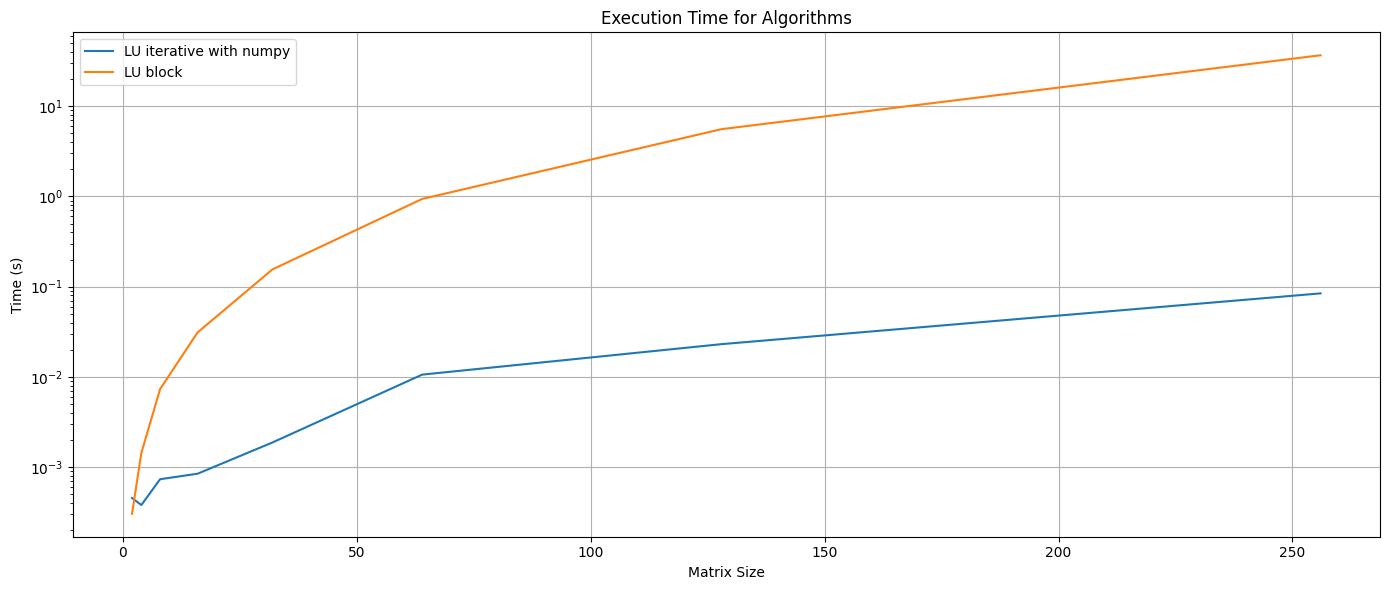

In [22]:
plot_times_all(sizes, [lu_numpy_times, lu_block_times], ["LU iterative with numpy", "LU block"])